In [1]:
# Mount Google Drive folder as a local folder
# Note: This mounts your entire drive, not the current folder
from google.colab import drive
drive.mount('/mydrive')

Mounted at /mydrive


In [2]:
# TODO replace the path with your path in drive
# This usually takes 15-20 minutes to run
!cp -r /mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset ./

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Sequential, Model

In [4]:
# TRAIN_PATH = '../input/fruits-fresh-and-rotten-for-classification/dataset/train/'
# TEST_PATH = '../input/fruits-fresh-and-rotten-for-classification/dataset/test/'
TRAIN_PATH = '/mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset/train/'
TEST_PATH = '/mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset/test/'
SIZE = (224, 224)

In [5]:
labels = []
for class_ in os.listdir(TRAIN_PATH):
    labels.append(class_)
NUM_LABELS = len(labels)

print(labels)

['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen=ImageDataGenerator(rescale=1./255, validation_split = 0.1)
test_datagen = ImageDataGenerator(rescale=1./255)

'''
Comments:
- ImageDataGenerator will resize all images to target_size
- x_col is the column where the images' names are
- y_col is the column where the labels are
- has_ext means that the images' names include a file extension, e.g. image_name.jpg
- Here you can change the targe_size to resize all images to different shapes.
Maybe larger images help in getting a better accuracy
'''
train_dataset = datagen.flow_from_directory(batch_size=32,
                                                 directory=TRAIN_PATH,
                                                 shuffle=True,
                                                classes=labels,
                                                 target_size=SIZE,
                                                 subset="training",
                                                 class_mode='categorical')

val_dataset = datagen.flow_from_directory(batch_size=32,
                                                 directory=TEST_PATH ,
                                                 shuffle=True,
                                                classes=labels,
                                                 target_size=SIZE,
                                                 subset="validation",
                                                 class_mode='categorical')

Found 9813 images belonging to 6 classes.
Found 268 images belonging to 6 classes.


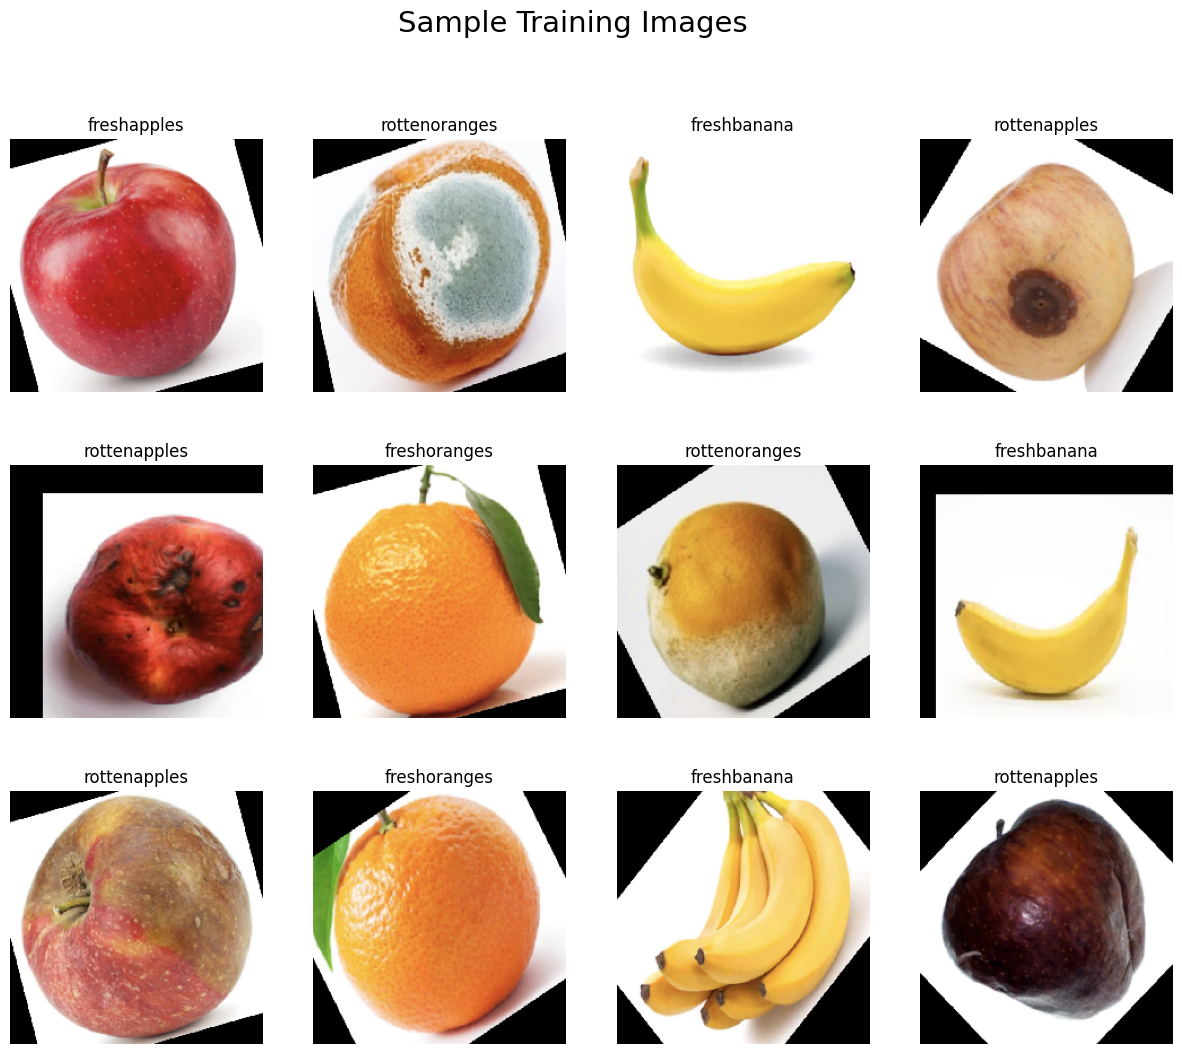

In [7]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(15, 12))
idx = 0

for i in range(3):
    for j in range(4):
        label = labels[np.argmax(train_dataset[0][1][idx])]
        ax[i, j].set_title(f"{label}")
        ax[i, j].imshow(train_dataset[0][0][idx][:, :, :])
        ax[i, j].axis("off")
        idx += 1

# plt.tight_layout()
plt.suptitle("Sample Training Images", fontsize=21)
plt.show()

In [8]:
from keras.applications.vgg19 import VGG19

In [9]:
from keras.models import Model
from keras.layers import Input, Dense
from tensorflow.keras.optimizers import  Adam


In [10]:
model = VGG19(
    include_top=True,
    weights="imagenet",
    input_tensor=Input(shape=(224, 224, 3)),
    input_shape=None,
    pooling=None,
    classes=6,
)


ValueError: If using `weights='imagenet'` with `include_top=True`, `classes` should be 1000.  Received classes=6

In [ ]:

from keras.callbacks import LearningRateScheduler

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
import keras
from keras.layers import *
from keras.models import *
from keras.preprocessing import image
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer="adam",metrics=['accuracy'])
model.summary()
epochs = 30
stepsperepoch=187
validationsteps=1
annealer = LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x)
es = EarlyStopping(monitor='val_acc', mode='max', verbose=1, patience=100)
mc = ModelCheckpoint("VGG16.h5", monitor='val_loss',save_best_only=True, mode='min',verbose=1)

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,31

 Total params: 139,594,822 (532.51 MB)

 Trainable params: 139,594,822 (532.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = model.fit(
    train_dataset,
    epochs=epochs,
    callbacks=[annealer,mc,es],
    steps_per_epoch=stepsperepoch,
    validation_data= val_dataset,
    validation_steps = validationsteps
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.1982 - loss: 1.7895
Epoch 1: val_loss improved from inf to 1.76024, saving model to VGG16.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 76s 293ms/step - accuracy: 0.1983 - loss: 1.7895 - val_accuracy: 0.2500 - val_loss: 1.7602 - learning_rate: 0.0010
Epoch 2/30
  2/187 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - accuracy: 0.1562 - loss: 1.7739

...

120/187 ━━━━━━━━━━━━━━━━━━━━ 14s 210ms/step - accuracy: 0.2113 - loss: 1.7737

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss did not improve from 1.76024
187/187 ━━━━━━━━━━━━━━━━━━━━ 25s 136ms/step - accuracy: 0.2109 - loss: 1.7744 - val_accuracy: 0.1875 - val_loss: 1.8047 - learning_rate: 9.5000e-04
Epoch 3/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.2109 - loss: 1.7754
Epoch 3: val_loss did not improve from 1.76024
187/187 ━━━━━━━━━━━━━━━━━━━━ 35s 188ms/step - accuracy: 0.2109 - loss: 1.7755 - val_accuracy: 0.2188 - val_loss: 1.7750 - learning_rate: 9.0250e-04
Epoch 4/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - accuracy: 0.2155 - loss: 1.7738
Epoch 4: val_loss did not improve from 1.76024
187/187 ━━━━━━━━━━━━━━━━━━━━ 22s 120ms/step - accuracy: 0.2130 - loss: 1.7752 - val_accuracy: 0.0938 - val_loss: 1.7764 - learning_rate: 8.5737e-04
Epoch 5/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.2250 - loss: 1.7768
Epoch 5: val_loss did not improve from 1.76024
187/187 ━━━━━━━━━━━━━━━━━━━━ 35s 188ms/step - accuracy: 0.2249 - loss: 1.7768 - val_accuracy: 0.1875 -

187/187 ━━━━━━━━━━━━━━━━━━━━ 39s 207ms/step - accuracy: 0.2123 - loss: 1.7773 - val_accuracy: 0.0938 - val_loss: 1.7386 - learning_rate: 7.3509e-04
Epoch 8/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 14s 216ms/step - accuracy: 0.2155 - loss: 1.7722
Epoch 8: val_loss did not improve from 1.73864
187/187 ━━━━━━━━━━━━━━━━━━━━ 26s 140ms/step - accuracy: 0.2137 - loss: 1.7735 - val_accuracy: 0.2188 - val_loss: 1.7949 - learning_rate: 6.9834e-04
Epoch 9/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.2002 - loss: 1.7777
Epoch 9: val_loss improved from 1.73864 to 1.72656, saving model to VGG16.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 39s 207ms/step - accuracy: 0.2002 - loss: 1.7777 - val_accuracy: 0.2812 - val_loss: 1.7266 - learning_rate: 6.6342e-04
Epoch 10/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 14s 211ms/step - accuracy: 0.2392 - loss: 1.7693
Epoch 10: val_loss did not improve from 1.72656
187/187 ━━━━━━━━━━━━━━━━━━━━ 25s 136ms/step - accuracy: 0.2331 - loss: 1.7708 - val_accuracy: 0.1875 - val_loss: 1.7855 - learning_rate: 6.3025e-04
Epoch 11/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.1982 - loss: 1.7749
Epoch 11: val_loss did not improve from 1.72656
187/187 ━━━━━━━━━━━━━━━━━━━━ 35s 187ms/step - accuracy: 0.1983 - loss: 1.7749 - val_accuracy: 0.1562 - val_loss: 1.7970 - learning_rate: 5.9874e-04
Epoch 12/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - accuracy: 0.2008 - loss: 1.7799
Epoch 12: val_loss did not improve from 1.72656
187/187 ━━━━━━━━━━━━━━━━━━━━ 22s 119ms/step - accuracy: 0.2022 - loss: 1.7792 - val_accuracy: 0.2500 - val_loss: 1.7971 - learning_rate: 5.6880

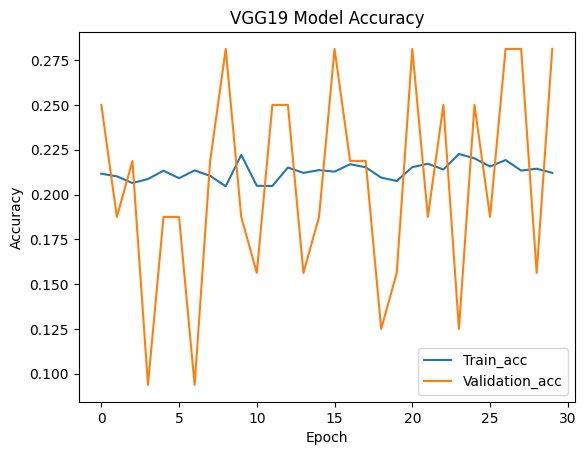

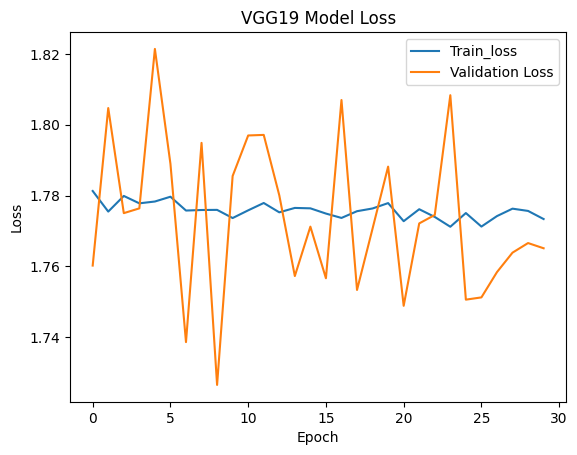

In [ ]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('VGG19 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(["Train_acc","Validation_acc"])
plt.show()

plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('VGG19 Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(["Train_loss","Validation Loss"])
plt.show()

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(TEST_PATH,
                                                  batch_size=1,
                                                  target_size=SIZE,
                                                  shuffle = False,
                                                  classes=labels,
                                                  class_mode='categorical')


filenames = test_generator.filenames
nb_samples = len(filenames)

loss, acc = model.evaluate(test_generator,steps = (nb_samples), verbose=1)
print('accuracy test: ',acc)
print('loss test: ',loss)

Found 2698 images belonging to 6 classes.
2698/2698 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.1378 - loss: 1.8448
accuracy test:  0.22275759279727936
loss test:  1.775862455368042


In [ ]:
predictions = model.predict(test_generator)
files=test_generator.filenames
class_dict=test_generator.class_indices # a dictionary of the form class name: class index
rev_dict={}
for key, value in class_dict.items():
    rev_dict[value]=key

for i, p in enumerate(predictions):
    index=np.argmax(p)
    klass=rev_dict[index]
    prob=p[index]

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


2094/2698 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step

In [ ]:
print(len(test_generator[0][0]))
print(test_generator[0][1].shape)

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(12, 10))
idx = 0

for i in range(3):
    for j in range(4):
        predicted_label = labels[np.argmax(predictions[idx])]
        ax[i, j].set_title(f"{predicted_label}")
        ax[i, j].imshow(test_generator[idx][0].reshape(224,224,3))
        ax[i, j].axis("off")
        idx += 200

# plt.tight_layout()
plt.suptitle("Test Dataset Predictions", fontsize=20)
plt.show()

In [ ]:
from tensorflow.keras.utils import plot_model
tf.keras.utils.plot_model(
model, to_file='model.png', show_shapes=True, show_dtype=False,
show_layer_names=True, rankdir='TB', expand_nested=False, dpi=96
)

In [ ]:
!pip install visualkeras

In [ ]:
from tensorflow.keras import layers
from collections import defaultdict
# from PIL import ImageFont
# font = ImageFont.truetype("arial.ttf", 12)
color_map = defaultdict(dict) #customize the colours
color_map[layers.Conv2D]['fill'] = '#00f5d4'
color_map[layers.MaxPooling2D]['fill'] = '#8338ec'
color_map[layers.Dropout]['fill'] = '#03045e'
color_map[layers.Dense]['fill'] = '#fb5607'
color_map[layers.Flatten]['fill'] = '#ffbe0b'
# visualkeras.layered_view(model, legend=True,color_map=color_map,scale_xy=2, scale_z=1, max_z=200)

In [ ]:
test_steps_per_epoch = int(np.ceil(test_generator.samples / test_generator.batch_size))

In [ ]:

predictions = model.predict(test_generator, steps=test_steps_per_epoch)
# Get most likely class
predicted_classes = np.argmax(predictions, axis=1)

In [ ]:
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

In [ ]:
print('Confusion Matrix')
# print(confusion_matrix(test_generator.classes, predicted_classes))
cm = confusion_matrix(test_generator.classes, predicted_classes)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(test_generator.classes, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax,cmap="cividis")